In [ ]:
!pip -q install kagglehub gradio scikit-learn tensorflow pandas numpy matplotlib pillow easyocr opencv-python-headless transformers torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 18.4 MB/s eta 0:00:00


In [ ]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime, date, timedelta

import cv2
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import kagglehub
import easyocr
import gradio as gr
from transformers import CLIPProcessor, CLIPModel
import torch

print("TensorFlow:", tf.__version__, "| Gradio:", gr.__version__)


TensorFlow: 2.20.0 | Gradio: 5.50.0


In [ ]:
dataset_path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")
print("Dataset downloaded to:", dataset_path)

def find_folder(base_path, possible_names):
    for root, dirs, files in os.walk(base_path):
        for d in dirs:
            if d.lower() in possible_names:
                return os.path.join(root, d)
    return None

train_dir = find_folder(dataset_path, {"train", "training"})
val_dir   = find_folder(dataset_path, {"validation", "valid", "val"})
test_dir  = find_folder(dataset_path, {"test", "testing"})

print("Train folder:", train_dir)
print("Validation folder:", val_dir)
print("Test folder:", test_dir)

if train_dir is None:
    raise ValueError("Train folder not found. Please check the dataset structure.")


100%|██████████| 1.98G/1.98G [01:53<00:00, 18.8MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8
Train folder: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8/train
Validation folder: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8/validation
Test folder: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8/test


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

if val_dir:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED)
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED)
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, validation_split=0.2, subset="training",
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED)
    val_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, validation_split=0.2, subset="validation",
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Number of classes:", num_classes)
print("Class names:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)


Found 3115 files belonging to 36 classes.
Found 351 files belonging to 36 classes.
Number of classes: 36
Class names: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


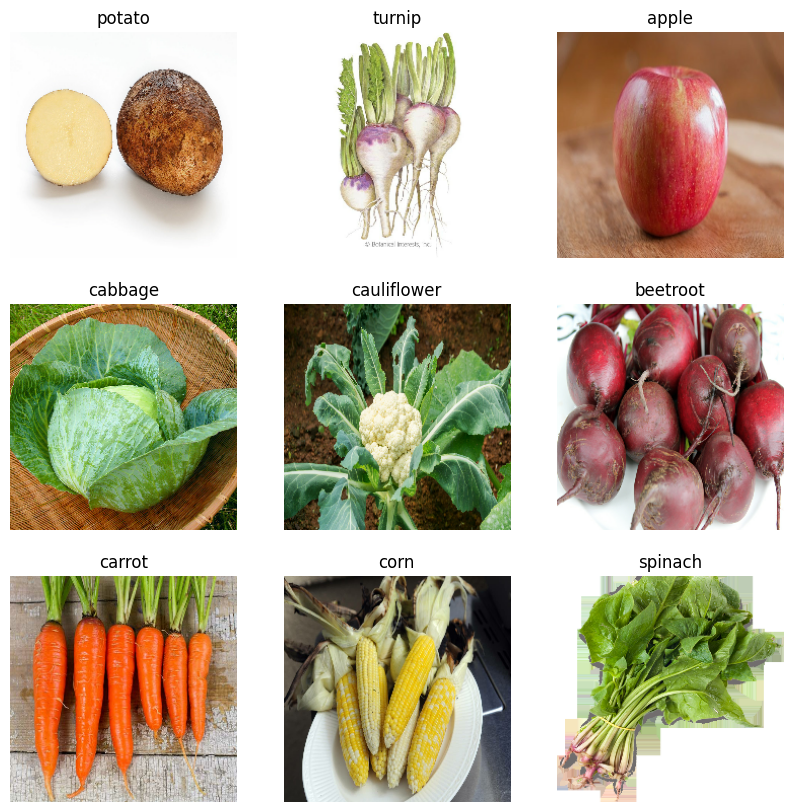

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
])

base_model = MobileNetV2(input_shape=IMG_SIZE + (3,),
                         include_top=False, weights="imagenet")
base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

food_model = tf.keras.Model(inputs, outputs)
food_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])
food_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 36)             │        46,116 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,304,100 (8.79 MB)

 Trainable params: 46,116 (180.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
checkpoint_path = "best_food_recognition_model.keras"
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True),
]
history = food_model.fit(train_ds, validation_data=val_ds, epochs=8, callbacks=callbacks)


Epoch 1/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 67s 571ms/step - accuracy: 0.3002 - loss: 2.6702 - val_accuracy: 0.7179 - val_loss: 1.3003
Epoch 2/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 56s 567ms/step - accuracy: 0.6465 - loss: 1.3001 - val_accuracy: 0.8205 - val_loss: 0.7506
Epoch 3/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 84s 594ms/step - accuracy: 0.7281 - loss: 0.9402 - val_accuracy: 0.8433 - val_loss: 0.5561
Epoch 4/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 80s 574ms/step - accuracy: 0.7807 - loss: 0.7763 - val_accuracy: 0.8775 - val_loss: 0.4624
Epoch 5/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 84s 595ms/step - accuracy: 0.7968 - loss: 0.6685 - val_accuracy: 0.8832 - val_loss: 0.4117
Epoch 6/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 83s 603ms/step - accuracy: 0.8234 - loss: 0.6012 - val_accuracy: 0.9031 - val_loss: 0.3621
Epoch 7/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 59s 609ms/step - accuracy: 0.8427 - loss: 0.5488 - val_accuracy: 0.9060 - val_loss: 0.3368
Epoch 8/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 79s 573ms/step - accuracy: 0.8469 - loss: 0.4993 - val_accuracy: 0.

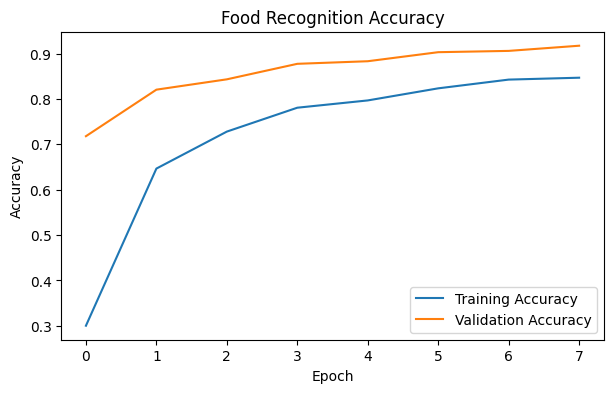

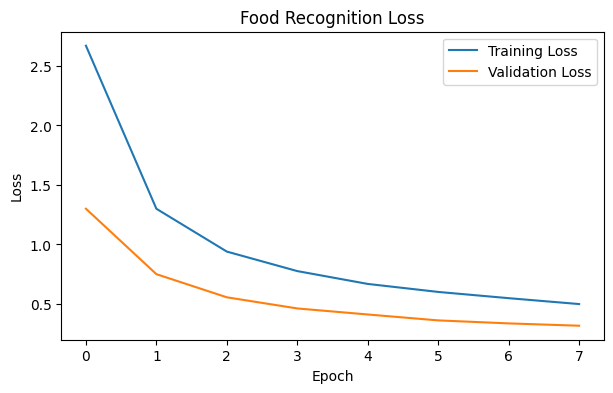

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Food Recognition Accuracy"); plt.legend(); plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Food Recognition Loss"); plt.legend(); plt.show()


In [ ]:
if test_dir:
    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)
    test_ds = test_ds.prefetch(tf.data.AUTOTUNE)
    test_loss, test_acc = food_model.evaluate(test_ds)
    print(f"\nTest accuracy on unseen images: {test_acc:.2%}")
else:
    print("No separate test folder found - skipping test evaluation.")


Found 359 files belonging to 36 classes.
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 681ms/step - accuracy: 0.9164 - loss: 0.3203

Test accuracy on unseen images: 91.64%


In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

food_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])
fine_tune_history = food_model.fit(train_ds, validation_data=val_ds,
                                   epochs=5, callbacks=callbacks)


Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 68s 573ms/step - accuracy: 0.7698 - loss: 0.7400 - val_accuracy: 0.8860 - val_loss: 0.3807
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 84s 610ms/step - accuracy: 0.8388 - loss: 0.5184 - val_accuracy: 0.8803 - val_loss: 0.3438
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 81s 603ms/step - accuracy: 0.8690 - loss: 0.4301 - val_accuracy: 0.9031 - val_loss: 0.3039


In [ ]:
clip_model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model = clip_model.to(device)
print("CLIP zero-shot model loaded on:", device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP zero-shot model loaded on: cuda


In [ ]:
clip_food_classes = [
    "yogurt", "milk", "cheese", "butter", "cream",
    "egg", "chicken", "beef", "pork", "fish", "shrimp", "tofu",
    "bread", "rice", "noodles", "pasta", "cooked leftover food", "sandwich",
    "juice", "soft drink", "bottled tea", "sauce", "jam",
    "unknown food",
]
clip_all_classes = list(dict.fromkeys(
    clip_food_classes + [c.replace("_", " ").replace("-", " ") for c in class_names]
))
print("CLIP can recognise", len(clip_all_classes), "food types")

def predict_with_cnn(image):
    img = image.convert("RGB").resize(IMG_SIZE)
    arr = np.expand_dims(np.array(img), axis=0)
    preds = food_model.predict(arr, verbose=0)[0]
    i = int(np.argmax(preds))
    return class_names[i].replace("_", " "), float(preds[i])

def predict_with_clip(image):
    image = image.convert("RGB")
    prompts = [f"a photo of {f}" for f in clip_all_classes]
    inputs = clip_processor(text=prompts, images=image,
                            return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        out = clip_model(**inputs)
        probs = out.logits_per_image.softmax(dim=1).cpu().numpy()[0]
    i = int(np.argmax(probs))
    return clip_all_classes[i], float(probs[i])

CNN_CONFIDENCE_THRESHOLD = 0.55

def recognize_food(image, mode="Auto (recommended)"):
    if image is None:
        return "unknown food", 0.0, "no image"
    if mode == "Fruits & Vegetables (trained CNN)":
        f, c = predict_with_cnn(image)
        return f, c, "trained MobileNetV2 CNN"
    if mode == "Any fridge food (CLIP)":
        f, c = predict_with_clip(image)
        return f, c, "CLIP zero-shot model"
    f, c = predict_with_cnn(image)
    if c >= CNN_CONFIDENCE_THRESHOLD:
        return f, c, "trained CNN"
    fc, cc = predict_with_clip(image)
    return fc, cc, "CLIP fallback (CNN was not confident)"

print("Hybrid recognition ready.")


CLIP can recognise 60 food types
Hybrid recognition ready.


In [ ]:
shelf_life_db = {
    # fruits & vegetables
    "banana": 5, "apple": 21, "orange": 21, "grapes": 7, "mango": 7,
    "pineapple": 5, "watermelon": 5, "kiwi": 14, "pear": 10, "pomegranate": 21,
    "lettuce": 5, "cabbage": 14, "carrot": 21, "potato": 30, "tomato": 7,
    "onion": 30, "cucumber": 7, "bell pepper": 10, "chilli pepper": 10,
    "corn": 5, "eggplant": 7, "garlic": 60, "ginger": 30, "jalapeno": 10,
    "lemon": 21, "peas": 5, "spinach": 5, "sweetcorn": 5, "sweetpotato": 21,
    "sweet potato": 21, "turnip": 14, "raddish": 14, "radish": 14,
    "capsicum": 10, "cauliflower": 7, "soy beans": 5, "paprika": 10, "beetroot": 21,
    # dairy / protein / cooked food / drinks
    "yogurt": 10, "milk": 7, "cheese": 21, "butter": 30, "cream": 7,
    "egg": 21, "chicken": 2, "beef": 3, "pork": 3, "fish": 2, "shrimp": 2,
    "tofu": 5, "bread": 5, "rice": 4, "noodles": 4, "pasta": 4,
    "cooked leftover food": 3, "sandwich": 2, "juice": 7, "soft drink": 30,
    "bottled tea": 14, "sauce": 30, "jam": 30, "unknown food": 5,
}

# Foods that become unsafe quickly once stored
HIGH_RISK_FOODS = {"chicken", "beef", "pork", "fish", "shrimp", "tofu",
                   "milk", "cream", "cooked leftover food", "sandwich", "egg"}

def normalize_food_name(name):
    return str(name).lower().replace("_", " ").replace("-", " ").strip()

def get_shelf_life(food_name):
    f = normalize_food_name(food_name)
    if f in shelf_life_db:
        return shelf_life_db[f]
    for k, v in shelf_life_db.items():
        if k in f or f in k:
            return v
    return 7

print("Knowledge base ready with", len(shelf_life_db), "foods.")


Knowledge base ready with 62 foods.


In [ ]:
np.random.seed(42)

def score_risk(food_name, days_stored, opened, days_until_expiry, storage_type):
    f = normalize_food_name(food_name)
    shelf = get_shelf_life(f)
    if storage_type == "freezer":
        shelf *= 3
    elif storage_type == "room temperature":
        shelf *= 0.5
    if opened == 1:
        shelf *= 0.65

    storage_ratio = days_stored / max(shelf, 1)

    if days_until_expiry <= 0:
        expiry_score = 1.0
    elif days_until_expiry <= 2:
        expiry_score = 0.85
    elif days_until_expiry <= 5:
        expiry_score = 0.55
    else:
        expiry_score = 0.2

    score = 0.62 * storage_ratio + 0.38 * expiry_score
    if f in HIGH_RISK_FOODS and days_stored >= 2 and storage_type != "freezer":
        score += 0.15
    return score

def label_from_score(score):
    if score >= 0.80:
        return "High Risk"
    if score >= 0.45:
        return "Medium Risk"
    return "Low Risk"

all_food_names = sorted(set(
    [normalize_food_name(c) for c in class_names] + list(shelf_life_db.keys())
))
storage_options = ["fridge", "freezer", "room temperature"]

rows = []
for _ in range(9000):
    food = np.random.choice(all_food_names)
    days_stored = int(np.random.randint(0, 31))
    opened = int(np.random.choice([0, 1]))
    days_until_expiry = int(np.random.randint(-3, 31))
    storage = np.random.choice(storage_options, p=[0.75, 0.10, 0.15])
    base = score_risk(food, days_stored, opened, days_until_expiry, storage)

    noisy = base + np.random.normal(0, 0.09)
    rows.append({"food_type": food, "days_stored": days_stored, "opened": opened,
                 "days_until_expiry": days_until_expiry, "storage_type": storage,
                 "risk": label_from_score(noisy)})

risk_df = pd.DataFrame(rows)
print(risk_df["risk"].value_counts())
risk_df.head()


risk
High Risk      5792
Low Risk       1705
Medium Risk    1503
Name: count, dtype: int64


,food_type,days_stored,opened,days_until_expiry,storage_type,risk
0,pasta,19,0,11,fridge,High Risk
1,cucumber,22,0,7,room temperature,High Risk
2,onion,7,1,-1,fridge,Medium Risk
3,eggplant,0,1,18,fridge,Low Risk
4,grapes,16,0,24,room temperature,High Risk


In [ ]:
X = risk_df.drop("risk", axis=1)
y = risk_df["risk"]
X_encoded = pd.get_dummies(X, columns=["food_type", "storage_type"], drop_first=False)
RISK_FEATURE_COLUMNS = list(X_encoded.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y)

risk_model = RandomForestClassifier(n_estimators=300, max_depth=14,
                                    random_state=42, class_weight="balanced")
risk_model.fit(X_train, y_train)
y_pred = risk_model.predict(X_test)

print("Expiry-risk model accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred))

def prepare_risk_input(food_type, days_stored, opened, days_until_expiry, storage_type):
    df = pd.DataFrame([{
        "food_type": normalize_food_name(food_type),
        "days_stored": int(days_stored),
        "opened": int(opened),
        "days_until_expiry": int(days_until_expiry),
        "storage_type": storage_type,
    }])
    enc = pd.get_dummies(df, columns=["food_type", "storage_type"], drop_first=False)
    return enc.reindex(columns=RISK_FEATURE_COLUMNS, fill_value=0)

def predict_risk(food_type, days_stored, opened, days_until_expiry, storage_type):
    enc = prepare_risk_input(food_type, days_stored, opened, days_until_expiry, storage_type)
    risk = risk_model.predict(enc)[0]
    probs = dict(zip(risk_model.classes_, risk_model.predict_proba(enc)[0]))
    return risk, probs


Expiry-risk model accuracy: 0.8061

              precision    recall  f1-score   support

   High Risk       0.94      0.88      0.91      1158
    Low Risk       0.69      0.86      0.76       341
 Medium Risk       0.49      0.48      0.48       301

    accuracy                           0.81      1800
   macro avg       0.71      0.74      0.72      1800
weighted avg       0.82      0.81      0.81      1800



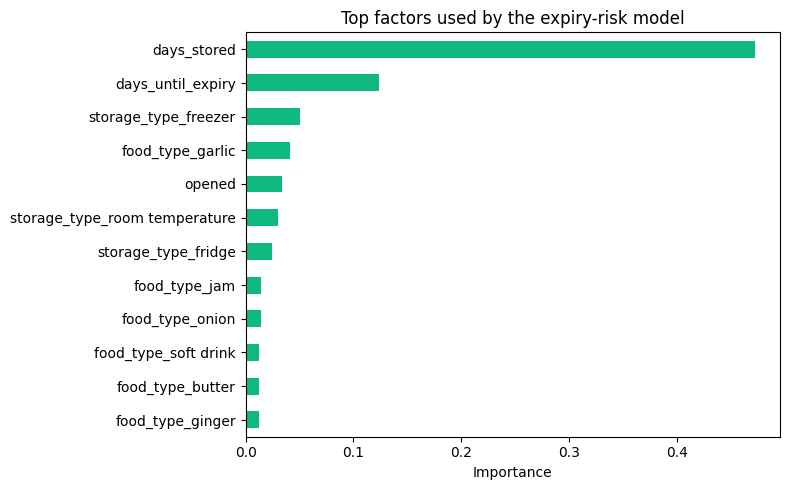

In [ ]:
importances = pd.Series(risk_model.feature_importances_, index=RISK_FEATURE_COLUMNS)
top = importances.sort_values(ascending=False).head(12)

plt.figure(figsize=(8, 5))
top.sort_values().plot(kind="barh", color="#10b981")
plt.title("Top factors used by the expiry-risk model")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [ ]:
ocr_reader = easyocr.Reader(['en'], gpu=False)

def preprocess_expiry_image(image):
    img = np.array(image.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    gray = cv2.equalizeHist(gray)
    return gray

def extract_text_from_expiry_image(image):
    if image is None:
        return ""
    processed = preprocess_expiry_image(image)
    results = ocr_reader.readtext(processed, detail=0)
    return " ".join(results)

def parse_expiry_date_from_text(text):
    if not text:
        return None
    t = text.lower()
    for noise in ["best before", "best by", "use by", "expiry", "expires", "exp", "bb"]:
        t = t.replace(noise, " ")
    t = t.replace(".", "/").replace(",", " ")
    t = re.sub(r"\s+", " ", t).strip()

    # YYYY-MM-DD or YYYY/MM/DD
    m = re.search(r"\b(20\d{2})[-/](\d{1,2})[-/](\d{1,2})\b", t)
    if m:
        y, mo, d = map(int, m.groups())
        try:
            return date(y, mo, d)
        except Exception:
            pass

    # DD-MM-YYYY or MM-DD-YYYY  (day-month order is tried first)
    for a, b, y in re.findall(r"\b(\d{1,2})[-/](\d{1,2})[-/](20\d{2})\b", t):
        a, b, y = int(a), int(b), int(y)
        for d, mo in [(a, b), (b, a)]:
            try:
                return date(y, mo, d)
            except Exception:
                pass

    # Month-name formats
    month_formats = ["%d %b %Y", "%d %B %Y", "%b %d %Y", "%B %d %Y",
                     "%d %b %y", "%d %B %y", "%b %d %y", "%B %d %y"]
    words = t.split()
    for i in range(len(words)):
        chunk = " ".join(words[i:i + 3])
        for fmt in month_formats:
            try:
                return datetime.strptime(chunk, fmt).date()
            except Exception:
                pass
    return None

def read_expiry_date_ocr(expiry_image):
    if expiry_image is None:
        return "", "No expiry image uploaded.", None
    text = extract_text_from_expiry_image(expiry_image)
    parsed = parse_expiry_date_from_text(text)
    if parsed is None:
        return text, "OCR could not find a clear date - manual input will be used.", None
    days_left = (parsed - date.today()).days
    return text, f"Detected expiry date {parsed.isoformat()} ({days_left} days left)", days_left

print("OCR reader ready.")


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteOCR reader ready.


In [ ]:
INVENTORY_PATH = "/content/fridge_inventory.csv"
INVENTORY_COLUMNS = ["id", "food", "storage", "opened",
                     "date_added", "days_stored_at_add", "expiry_date"]

def load_inventory():
    if os.path.exists(INVENTORY_PATH):
        try:
            df = pd.read_csv(INVENTORY_PATH, dtype=str).fillna("")
            for c in INVENTORY_COLUMNS:
                if c not in df.columns:
                    df[c] = ""
            return df[INVENTORY_COLUMNS]
        except Exception:
            pass
    return pd.DataFrame(columns=INVENTORY_COLUMNS)

def save_inventory(df):
    df.to_csv(INVENTORY_PATH, index=False)

def add_to_inventory(food, storage, opened, days_stored, expiry_date):
    df = load_inventory()
    new_id = "1" if len(df) == 0 else str(df["id"].astype(int).max() + 1)
    row = {
        "id": new_id,
        "food": str(food),
        "storage": str(storage),
        "opened": str(int(opened)),
        "date_added": date.today().isoformat(),
        "days_stored_at_add": str(int(days_stored)),
        "expiry_date": expiry_date.isoformat() if expiry_date else "",
    }
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    save_inventory(df)
    return new_id

def remove_from_inventory(item_id):
    df = load_inventory()
    df = df[df["id"].astype(str) != str(item_id).strip()]
    save_inventory(df)

def clear_inventory():
    save_inventory(pd.DataFrame(columns=INVENTORY_COLUMNS))

def compute_fridge_status():
    df = load_inventory()
    today = date.today()
    items = []
    for _, r in df.iterrows():
        try:
            added = datetime.fromisoformat(str(r["date_added"])).date()
        except Exception:
            added = today
        days_since = (today - added).days
        try:
            base_stored = int(float(r["days_stored_at_add"] or 0))
        except Exception:
            base_stored = 0
        days_stored = base_stored + days_since

        if r["expiry_date"]:
            try:
                exp = datetime.fromisoformat(str(r["expiry_date"])).date()
                days_until_expiry = (exp - today).days
            except Exception:
                days_until_expiry = 7
        else:
            days_until_expiry = 7

        opened = 1 if str(r["opened"]) in ("1", "1.0", "Opened") else 0
        risk, _ = predict_risk(r["food"], days_stored, opened,
                               days_until_expiry, r["storage"])
        items.append({
            "id": str(r["id"]), "food": str(r["food"]), "storage": str(r["storage"]),
            "opened": "Opened" if opened else "Unopened",
            "days_stored": days_stored, "days_until_expiry": days_until_expiry,
            "risk": risk,
        })
    rank = {"High Risk": 0, "Medium Risk": 1, "Low Risk": 2}
    items.sort(key=lambda x: (rank.get(x["risk"], 3), x["days_until_expiry"]))
    return items

print("Fridge inventory system ready.")


Fridge inventory system ready.


In [ ]:
RISK_COLORS = {"High Risk": "#e5484d", "Medium Risk": "#f5a623", "Low Risk": "#30a46c"}

FOOD_EMOJI = {
    "banana": "🍌", "apple": "🍎", "orange": "🍊",
    "grapes": "🍇", "mango": "🥭", "watermelon": "🍉",
    "pineapple": "🍍", "lemon": "🍋", "pear": "🍐",
    "kiwi": "🥝", "milk": "🥛", "cheese": "🧀",
    "yogurt": "🥣", "butter": "🧈", "cream": "🥛",
    "egg": "🥚", "chicken": "🍗", "beef": "🥩",
    "pork": "🥓", "fish": "🐟", "shrimp": "🦐",
    "tofu": "🍲", "bread": "🍞", "rice": "🍚",
    "noodles": "🍜", "pasta": "🍝", "sandwich": "🥪",
    "juice": "🧃", "sauce": "🥫", "jam": "🍯",
    "carrot": "🥕", "tomato": "🍅", "potato": "🥔",
    "corn": "🌽", "cucumber": "🥒", "bell pepper": "🫑",
    "eggplant": "🍆", "garlic": "🧄", "onion": "🧅",
    "lettuce": "🥬", "cabbage": "🥬", "spinach": "🥬",
}

def food_emoji(name):
    n = normalize_food_name(name)
    if n in FOOD_EMOJI:
        return FOOD_EMOJI[n]
    for k, v in FOOD_EMOJI.items():
        if k in n or n in k:
            return v
    return "🍽️"

def get_recommendation(risk, food, days_left):
    if risk == "High Risk":
        return f"Eat or cook your {food} today - it is likely to spoil very soon."
    if risk == "Medium Risk":
        return f"Plan to use your {food} within the next 1-3 days."
    return f"Your {food} is still in good shape. Keep storing it properly."

def risk_badge(risk):
    c = RISK_COLORS.get(risk, "#888")
    return (f"<span style='background:{c};color:white;padding:3px 10px;"
            f"border-radius:20px;font-size:12px;font-weight:600'>{risk}</span>")

def build_result_card(food, conf, source, ocr_text, expiry_source,
                      days_left, risk, probs, rec):
    color = RISK_COLORS.get(risk, "#888")
    bars = ""
    for cls in ["High Risk", "Medium Risk", "Low Risk"]:
        p = float(probs.get(cls, 0.0))
        c = RISK_COLORS[cls]
        bars += ("<div style='display:flex;align-items:center;gap:8px;margin:3px 0'>"
                 f"<span style='width:86px;font-size:12px;color:#555'>{cls}</span>"
                 "<div style='flex:1;background:#eee;border-radius:6px;height:13px'>"
                 f"<div style='width:{p*100:.0f}%;background:{c};height:13px;"
                 "border-radius:6px'></div></div>"
                 f"<span style='width:40px;font-size:12px;text-align:right'>{p:.0%}</span></div>")
    ocr_line = ""
    if ocr_text:
        ocr_line = (f"<div style='font-size:12px;color:#999;margin-top:6px'>"
                    f"OCR read: {ocr_text[:60]}</div>")
    parts = [
        f"<div style='border:1px solid #e5e5e5;border-left:6px solid {color};"
        "border-radius:12px;padding:18px;background:white'>",
        f"<div style='font-size:40px'>{food_emoji(food)}</div>",
        f"<div style='font-size:21px;font-weight:700;text-transform:capitalize'>{food}</div>",
        f"<div style='font-size:12px;color:#888'>Recognised with {conf:.0%} "
        f"confidence &middot; {source}</div>",
        f"<div style='margin:12px 0'>{risk_badge(risk)}</div>",
        f"<div style='font-size:13px;color:#444;margin-bottom:8px'>{expiry_source} "
        f"&middot; <b>{days_left}</b> day(s) until expiry</div>",
        bars, ocr_line,
        f"<div style='margin-top:12px;padding:10px 12px;background:#f3faf6;"
        f"border-radius:8px;font-size:14px'>💡 <b>Recommendation:</b> {rec}</div>",
        "</div>",
    ]
    return "".join(parts)

def stat_card(value, label, color):
    return (f"<div style='flex:1;background:white;border:1px solid #eee;"
            f"border-radius:12px;padding:14px;text-align:center'>"
            f"<div style='font-size:26px;font-weight:700;color:{color}'>{value}</div>"
            f"<div style='font-size:12px;color:#777'>{label}</div></div>")

def render_fridge_html():
    items = compute_fridge_status()
    total = len(items)
    high = sum(1 for i in items if i["risk"] == "High Risk")
    soon = sum(1 for i in items if i["days_until_expiry"] <= 2)

    if total == 0:
        banner = ("<div style='padding:16px;background:#f3faf6;border-radius:10px;"
                  "text-align:center;color:#555'>🧊 Your fridge is empty. "
                  "Scan a food item and add it here!</div>")
    elif high > 0 or soon > 0:
        urgent = [i for i in items if i["risk"] == "High Risk" or i["days_until_expiry"] <= 2]
        names = ", ".join(f"{food_emoji(i['food'])} {i['food']}" for i in urgent[:6])
        banner = (f"<div style='padding:14px 16px;background:#fdecec;"
                  f"border:1px solid #f5b5b7;border-radius:10px;color:#a3262a;"
                  f"font-weight:600'>🔔 Reminder: eat these soon &mdash; {names}</div>")
    else:
        banner = ("<div style='padding:14px 16px;background:#eafaf1;"
                  "border:1px solid #b6e5cb;border-radius:10px;color:#1d7a4d;"
                  "font-weight:600'>✅ All good! Nothing urgent in your fridge today.</div>")

    stats = ("<div style='display:flex;gap:10px;margin:12px 0'>"
             + stat_card(total, "Items in fridge", "#10b981")
             + stat_card(high, "High risk", "#e5484d")
             + stat_card(soon, "Expiring within 2 days", "#f5a623")
             + "</div>")

    cards = ""
    for i in items:
        color = RISK_COLORS.get(i["risk"], "#888")
        de = i["days_until_expiry"]
        if de > 0:
            de_text = f"{de} day(s) left"
        elif de == 0:
            de_text = "expires today"
        else:
            de_text = f"{abs(de)} day(s) overdue"
        cards += (
            f"<div style='width:215px;border:1px solid #eee;"
            f"border-top:5px solid {color};border-radius:12px;padding:14px;"
            "background:white'>"
            "<div style='display:flex;justify-content:space-between;"
            "align-items:center'>"
            f"<span style='font-size:30px'>{food_emoji(i['food'])}</span>"
            f"<span style='font-size:11px;color:#aaa'>#{i['id']}</span></div>"
            f"<div style='font-weight:700;text-transform:capitalize;"
            f"margin-top:4px'>{i['food']}</div>"
            f"<div style='margin:6px 0'>{risk_badge(i['risk'])}</div>"
            f"<div style='font-size:12px;color:#666'>📅 {de_text}</div>"
            f"<div style='font-size:12px;color:#666'>❄️ {i['storage']} "
            f"&middot; {i['opened']}</div>"
            f"<div style='font-size:12px;color:#666'>⏱️ stored "
            f"{i['days_stored']} day(s)</div>"
            "</div>"
        )
    grid = (f"<div style='display:flex;flex-wrap:wrap;gap:12px;"
            f"margin-top:6px'>{cards}</div>")
    return banner + stats + grid

print("Display helpers ready.")


Display helpers ready.


In [ ]:
def analyze(food_img, expiry_img, days_stored, opened_status,
            manual_days, storage, mode):
    if food_img is None:
        return ("<div style='padding:14px;color:#a3262a'>"
                "⚠️ Please upload a food photo first.</div>", None)

    food, conf, source = recognize_food(food_img, mode)

    ocr_text, ocr_msg, ocr_days = read_expiry_date_ocr(expiry_img)
    if ocr_days is not None:
        days_left = int(ocr_days)
        expiry_source = "📅 Expiry date read by OCR"
    else:
        days_left = int(manual_days)
        expiry_source = "✍️ Manual expiry input (OCR found no clear date)"
    expiry_date = date.today() + timedelta(days=days_left)

    opened = 1 if opened_status == "Opened" else 0
    risk, probs = predict_risk(food, days_stored, opened, days_left, storage)
    rec = get_recommendation(risk, food, days_left)

    card = build_result_card(food, conf, source, ocr_text, expiry_source,
                             days_left, risk, probs, rec)
    analysis = {
        "food": food, "storage": storage, "opened": opened,
        "days_stored": int(days_stored), "expiry_date": expiry_date.isoformat(),
        "risk": risk,
    }
    return card, analysis

def add_to_fridge(analysis):
    if not analysis:
        return ("<div style='padding:10px;color:#a3262a'>"
                "⚠️ Analyze a food item first.</div>", render_fridge_html())
    exp = datetime.fromisoformat(analysis["expiry_date"]).date()
    new_id = add_to_inventory(analysis["food"], analysis["storage"],
                              analysis["opened"], analysis["days_stored"], exp)
    msg = (f"<div style='padding:10px;background:#eafaf1;border-radius:8px;"
           f"color:#1d7a4d'>✅ Added {food_emoji(analysis['food'])} "
           f"{analysis['food']} to your fridge as item #{new_id}.</div>")
    return msg, render_fridge_html()

def remove_item(item_id):
    if item_id and str(item_id).strip():
        remove_from_inventory(item_id)
    return render_fridge_html()

def clear_all():
    clear_inventory()
    return render_fridge_html()

print("Action functions ready.")


Action functions ready.


In [ ]:
import requests
from getpass import getpass

LINE_CHANNEL_ACCESS_TOKEN = getpass("Paste your LINE Channel Access Token: ")

def send_line_message(line_user_id, message):
    line_user_id = line_user_id.strip()
    token = LINE_CHANNEL_ACCESS_TOKEN.strip()

    url = "https://api.line.me/v2/bot/message/push"

    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {token}"
    }

    data = {
        "to": line_user_id,
        "messages": [
            {
                "type": "text",
                "text": message
            }
        ]
    }

    response = requests.post(url, headers=headers, json=data)

    print("LINE status code:", response.status_code)
    print("LINE response:", response.text)

    if response.status_code == 200:
        return "LINE reminder sent successfully."
    else:
        return f"LINE reminder failed. Status: {response.status_code}. Response: {response.text}"


def send_latest_line_from_interface(line_user_id, send_to_line, last_analysis):
    try:
        if not send_to_line:
            return "<b>LINE reminder was not sent.</b><br>Please check the box first."

        if line_user_id is None or line_user_id.strip() == "":
            return "<b>Error:</b><br>Please enter your LINE User ID."

        if last_analysis is not None:
            food = last_analysis.get("food", last_analysis.get("food_name", "Unknown food"))
            risk = last_analysis.get("risk", last_analysis.get("risk_level", "Unknown risk"))
            days_until_expiry = last_analysis.get("days_until_expiry", "Unknown")
            storage_type = last_analysis.get("storage_type", last_analysis.get("storage", "Unknown"))
            opened_status = last_analysis.get("opened_status", last_analysis.get("package_status", "Unknown"))

            reminder_message = last_analysis.get(
                "reminder_message",
                f"{food} has {risk}. Please check it soon."
            )

            line_message = f"""AI Fridge Reminder

Food: {food}
Risk Level: {risk}
Days Until Expiry: {days_until_expiry}
Storage Type: {storage_type}
Package Status: {opened_status}

Reminder:
{reminder_message}
"""

            line_status = send_line_message(line_user_id.strip(), line_message)
            return f"<b>LINE Status:</b><br>{line_status}"

        if "reminder_list" in globals() and len(reminder_list) > 0:
            latest = reminder_list[-1]

            line_message = f"""AI Fridge Reminder

Food: {latest.get('food', 'Unknown')}
Risk Level: {latest.get('risk', 'Unknown')}
Days Until Expiry: {latest.get('days_until_expiry', 'Unknown')}
Storage Type: {latest.get('storage_type', 'Unknown')}
Package Status: {latest.get('opened_status', 'Unknown')}
Reminder Date: {latest.get('reminder_date', 'Unknown')}
Priority: {latest.get('priority', 'Unknown')}

Reminder:
{latest.get('reminder_message', 'Please check this food soon.')}
"""

            line_status = send_line_message(line_user_id.strip(), line_message)
            return f"<b>LINE Status:</b><br>{line_status}"

        return "<b>Error:</b><br>No reminder found. Please analyze food first."

    except Exception as e:
        return f"<b>Real Error:</b><br>{type(e).__name__}: {str(e)}"

In [ ]:
test_user_id = input("Paste your LINE User ID here: ").strip()
test_message = "Test message from AI Smart Fridge."

send_line_message(test_user_id, test_message)

In [ ]:
custom_css = """
.gradio-container {
    font-family: 'Segoe UI', system-ui, sans-serif;
}

#fridge-header {
    background: linear-gradient(135deg, #10b981, #059669);
    color: white;
    padding: 24px 28px;
    border-radius: 18px;
    margin-bottom: 12px;
    box-shadow: 0 8px 20px rgba(0,0,0,0.12);
}

#fridge-header h1 {
    margin: 0;
    font-size: 28px;
    font-weight: 800;
}

#fridge-header p {
    margin: 8px 0 0;
    opacity: 0.95;
    font-size: 15px;
}

#info-box {
    background: #ecfdf5;
    border: 1px solid #bbf7d0;
    padding: 14px 18px;
    border-radius: 14px;
    margin-bottom: 12px;
}

#warning-box {
    background: #fff7ed;
    border: 1px solid #fed7aa;
    padding: 14px 18px;
    border-radius: 14px;
    margin-bottom: 12px;
}
"""

header_html = """
<div id="fridge-header">
    <h1>🧊 AI Smart Fridge</h1>
    <p>Recognize food • read expiry dates • predict spoilage risk • create reminders • send LINE reminder</p>
</div>
"""

intro_html = """
<div id="info-box">
<b>Try the AI:</b> Upload a food photo and an expiry-date photo.
The system will recognize the food, read the expiry date, predict the risk, and create a reminder.
</div>
"""

line_note_html = """
<div id="warning-box">
<b>LINE Reminder:</b> To send reminders to LINE, paste your LINE User ID and check “Send reminder to LINE”.
Your LINE Official Account must already be added as a friend.
</div>
"""

how_it_works = """
### How the System Works

1. **Upload Food Photo**
   The AI recognizes the food item, such as yogurt, milk, eggs, bread, fruit, or vegetables.

2. **Upload Expiry-Date Photo**
   OCR reads the expiry date from the food label. If OCR fails, the manual input is used.

3. **Enter Storage Information**
   Users enter days stored, package status, and storage location.

4. **AI Predicts Spoilage Risk**
   The Random Forest model predicts **Low Risk**, **Medium Risk**, or **High Risk**.

5. **Reminder System**
   The system creates a reminder message and saves it into the fridge list.

6. **LINE Reminder**
   The latest reminder can be sent directly to the user’s LINE account.
"""

with gr.Blocks(
    theme=gr.themes.Soft(primary_hue="emerald"),
    css=custom_css,
    title="AI Smart Fridge"
) as demo:

    gr.HTML(header_html)
    gr.HTML(intro_html)

    last_analysis = gr.State(None)

    with gr.Tabs():

        with gr.Tab("📷 Scan Food"):
            with gr.Row():

                with gr.Column(scale=1):
                    gr.Markdown("### 1. Upload Food Information")

                    food_in = gr.Image(
                        type="pil",
                        label="Food Photo",
                        height=260
                    )

                    expiry_in = gr.Image(
                        type="pil",
                        label="Expiry-Date Label Photo",
                        height=220
                    )

                    mode_in = gr.Radio(
                        [
                            "Auto (recommended)",
                            "Fruits & Vegetables (trained CNN)",
                            "Any fridge food (CLIP)"
                        ],
                        value="Auto (recommended)",
                        label="Recognition Mode"
                    )

                    with gr.Row():
                        days_in = gr.Number(
                            value=1,
                            precision=0,
                            label="Days Already Stored"
                        )

                        manual_in = gr.Number(
                            value=5,
                            precision=0,
                            label="Days Until Expiry if OCR Fails"
                        )

                    opened_in = gr.Radio(
                        ["Unopened", "Opened"],
                        value="Unopened",
                        label="Package Status"
                    )

                    storage_in = gr.Radio(
                        ["fridge", "freezer", "room temperature"],
                        value="fridge",
                        label="Storage Location"
                    )

                    analyze_btn = gr.Button(
                        "🔍 Analyze Food",
                        variant="primary"
                    )

                with gr.Column(scale=1):
                    gr.Markdown("### 2. AI Result")

                    result_out = gr.HTML(
                        label="AI Analysis Result"
                    )

                    add_btn = gr.Button(
                        "➕ Add this item to My Fridge",
                        variant="secondary"
                    )

                    add_msg = gr.HTML()

        with gr.Tab("💬 LINE Reminder"):
            gr.HTML(line_note_html)

            gr.Markdown("### Send the Latest Reminder to LINE")

            with gr.Row():
                line_user_id_in = gr.Textbox(
                    label="LINE User ID",
                    placeholder="Paste your correct LINE User ID here, starting with U..."
                )

                send_line_checkbox = gr.Checkbox(
                    label="Send reminder to LINE",
                    value=False
                )

            line_btn = gr.Button(
                "📩 Send Latest Reminder to LINE",
                variant="primary"
            )

            line_status_out = gr.HTML()

            gr.Markdown(
                """
                **Important:**
                Before sending LINE reminders:
                - Paste your LINE Channel Access Token when Colab asks.
                - Add your LINE Official Account as a friend.
                - Paste the correct LINE User ID.
                - Analyze a food item first.
                """
            )

        with gr.Tab("🧊 My Fridge"):
            gr.Markdown("### Saved Fridge Items and Reminders")

            with gr.Row():
                refresh_btn = gr.Button(
                    "🔄 Refresh Reminders",
                    variant="primary"
                )

                clear_btn = gr.Button(
                    "🗑️ Clear All Items",
                    variant="stop"
                )

            fridge_out = gr.HTML(render_fridge_html())

            with gr.Row():
                remove_id = gr.Textbox(
                    label="Remove Item by ID",
                    placeholder="Example: 3"
                )

                remove_btn = gr.Button(
                    "Remove Item"
                )

        with gr.Tab("📱 Exhibition Demo"):
            gr.Markdown(
                """
                ### How Visitors Can Try the AI

                **Option 1: Use our laptop**
                1. Upload a food photo.
                2. Upload an expiry-date photo.
                3. Click **Analyze Food**.
                4. Open **LINE Reminder** if you want to send the reminder to LINE.

                **Option 2: Scan QR Code**
                1. Run the Colab notebook.
                2. Copy the Gradio public link.
                3. Generate a QR code.
                4. Visitors scan the QR and test the AI on their phone.

                **Recommended demo foods:**
                - Yogurt
                - Milk
                - Eggs
                - Bread
                - Banana
                - Tomato
                """
            )

        with gr.Tab("ℹ️ How It Works"):
            gr.Markdown(how_it_works)

    analyze_btn.click(
        analyze,
        inputs=[
            food_in,
            expiry_in,
            days_in,
            opened_in,
            manual_in,
            storage_in,
            mode_in
        ],
        outputs=[
            result_out,
            last_analysis
        ]
    )

    add_btn.click(
        add_to_fridge,
        inputs=[
            last_analysis
        ],
        outputs=[
            add_msg,
            fridge_out
        ]
    )

    refresh_btn.click(
        lambda: render_fridge_html(),
        inputs=None,
        outputs=fridge_out
    )

    clear_btn.click(
        clear_all,
        inputs=None,
        outputs=fridge_out
    )

    remove_btn.click(
        remove_item,
        inputs=[
            remove_id
        ],
        outputs=[
            fridge_out
        ]
    )

    line_btn.click(
        send_latest_line_from_interface,
        inputs=[
            line_user_id_in,
            send_line_checkbox,
            last_analysis
        ],
        outputs=[
            line_status_out
        ]
    )

demo.launch(debug=True, share=True)

# Presentation explanation

Our project is an **AI Smart Fridge** that helps students manage food and reduce waste.

We started from a simple idea — an expiry-date reminder — but a plain reminder app does not really need AI. So we made it intelligent in several connected ways. First, it **recognises food from a photo**: a CNN trained on a Kaggle fruit-and-vegetable dataset handles produce, and a CLIP zero-shot model handles other fridge foods such as yogurt, cheese, milk, eggs, meat and bread, without us needing to collect new training images. Second, it **reads the printed expiry date** from a label photo using OCR. Third, a **machine-learning model predicts spoilage risk** from the food type, storage time, opened status, days until expiry and storage location.

Finally, the system has a real **reminder feature**: scanned items are saved to a virtual fridge, and a dashboard sorts everything by urgency and highlights what should be eaten first. Because the system stores the real expiry date and recomputes risk for the current day, the reminder stays accurate over time on its own.

This makes the project genuinely AI-driven: it does not only remind the user — it **sees, reads, analyses, predicts and prioritises.**
